In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 기초 특성 파악

In [3]:
df = pd.read_csv('prj_data_cleaned.csv')
print(df.shape)
df.head()

(500, 22)


,고객ID,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부,멤버십등급_encoded,성별_남,성별_여,거주지역_경기,...,거주지역_부산,거주지역_서울,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y,건당평균구매금액,연령대
0,C0001,-1.473866,-0.498053,-0.183592,-0.805421,1,1,True,False,False,...,False,False,False,True,False,False,True,False,-0.471432,20대
1,C0002,1.031289,2.018989,2.273239,1.787932,0,3,False,True,False,...,True,False,False,False,True,False,False,True,-0.348047,50대
2,C0003,0.613763,-1.182477,-1.076986,-0.805421,0,0,False,True,False,...,False,False,False,True,False,False,False,True,-0.332295,50대
3,C0004,-0.221289,-0.309411,-1.076986,0.120776,0,1,False,True,True,...,False,False,False,True,False,False,True,False,1.211928,30대
4,C0005,-0.221289,0.465858,-0.183592,2.158411,0,2,True,False,True,...,False,False,False,False,True,False,True,False,0.259242,30대


In [4]:
df.dtypes

고객ID                 str
나이               float64
월평균구매금액          float64
구매횟수             float64
리뷰점수             float64
이탈여부               int64
멤버십등급_encoded      int64
성별_남                bool
성별_여                bool
거주지역_경기             bool
거주지역_기타             bool
거주지역_대구             bool
거주지역_부산             bool
거주지역_서울             bool
가입경로_광고             bool
가입경로_앱              bool
가입경로_웹              bool
가입경로_지인추천           bool
쿠폰사용여부_N            bool
쿠폰사용여부_Y            bool
건당평균구매금액         float64
연령대                  str
dtype: object

In [5]:
df.describe()

,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부,멤버십등급_encoded,건당평균구매금액
count,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,500.000000,500.000000,5.000000e+02
mean,1.065814e-17,8.881784e-17,-2.131628e-17,-6.377121e-16,0.380000,1.058000,1.154632e-16
std,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,0.485873,1.022118,1.001002e+00
min,-1.752216e+00,-1.426102e+00,-1.523682e+00,-2.287338e+00,0.000000,0.000000,-1.174920e+00
25%,-7.779896e-01,-8.035115e-01,-8.536373e-01,-6.201819e-01,0.000000,0.000000,-4.901749e-01
50%,-1.252577e-02,-2.411195e-01,-1.835923e-01,-6.446335e-02,0.000000,1.000000,-2.571468e-01
75%,8.921133e-01,6.060669e-01,5.422898e-01,6.764947e-01,1.000000,2.000000,8.219864e-02
max,1.796752e+00,2.720435e+00,2.943284e+00,2.343650e+00,1.000000,3.000000,6.570926e+00


In [6]:
# 수치형 변수
num_cols = ['나이', '월평균구매금액', '구매횟수', '리뷰점수', '건당평균구매금액']

# 범주형 변수
cat_cols = [
    '멤버십등급_encoded', '연령대', '이탈여부',
    '성별_남', '성별_여',
    '거주지역_경기', '거주지역_기타', '거주지역_대구', '거주지역_부산', '거주지역_서울',
    '가입경로_광고', '가입경로_앱', '가입경로_웹', '가입경로_지인추천',
    '쿠폰사용여부_N', '쿠폰사용여부_Y'
]

In [7]:
num_cols

['나이', '월평균구매금액', '구매횟수', '리뷰점수', '건당평균구매금액']

In [8]:
cat_cols

['멤버십등급_encoded',
 '연령대',
 '이탈여부',
 '성별_남',
 '성별_여',
 '거주지역_경기',
 '거주지역_기타',
 '거주지역_대구',
 '거주지역_부산',
 '거주지역_서울',
 '가입경로_광고',
 '가입경로_앱',
 '가입경로_웹',
 '가입경로_지인추천',
 '쿠폰사용여부_N',
 '쿠폰사용여부_Y']

In [9]:
# 범주형 변수 빈도 확인 - 연령대
df['연령대'].value_counts()

연령대
40대      125
20대       96
50대       96
30대       88
60대이상     73
10대       22
Name: count, dtype: int64

In [10]:
# 범주형 변수 빈도 확인 - 멤버십등급 (0=브론즈, 1=실버, 2=골드, 3=VIP)
df['멤버십등급_encoded'].value_counts().sort_index()

멤버십등급_encoded
0    192
1    142
2    111
3     55
Name: count, dtype: int64

## 2. 단변량 / 분포 시각화

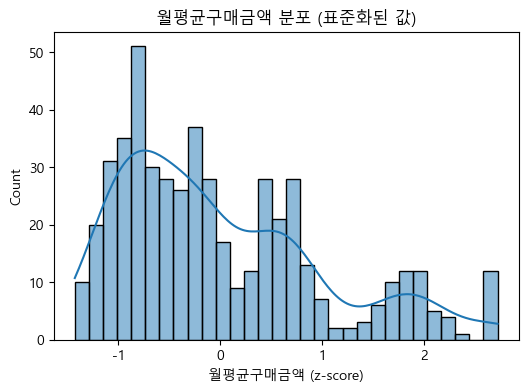

In [11]:
plt.figure(figsize=(6, 4))
sns.histplot(df['월평균구매금액'], bins=30, kde=True)
plt.title('월평균구매금액 분포 (표준화된 값)')
plt.xlabel('월평균구매금액 (z-score)')
plt.show()

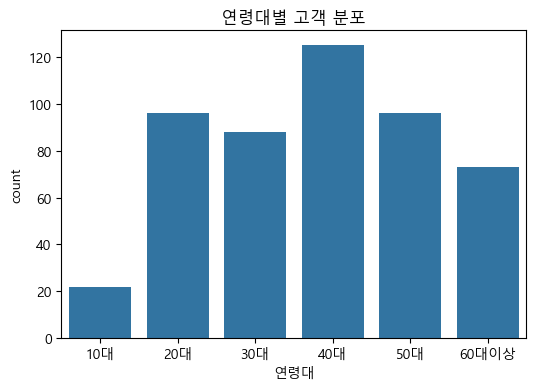

In [12]:
plt.figure(figsize=(6, 4))
order = ['10대', '20대', '30대', '40대', '50대', '60대이상']
sns.countplot(x='연령대', data=df, order=order)
plt.title('연령대별 고객 분포')
plt.show()

### 해석

- 월평균구매금액은 0(평균) 부근에 데이터가 몰려 있고 오른쪽으로 약간 긴 꼬리를 가지는 형태다. 소수의 고액 구매 고객이 오른쪽 꼬리를 형성하는 치우침이 남아있다.
- 연령대는 40대(125명)가 가장 많고 10대(22명)가 가장 적어, 30~50대 고객 비중이 높은 구간을 보인다.

## 3. 상관관계 및 이변량 분석

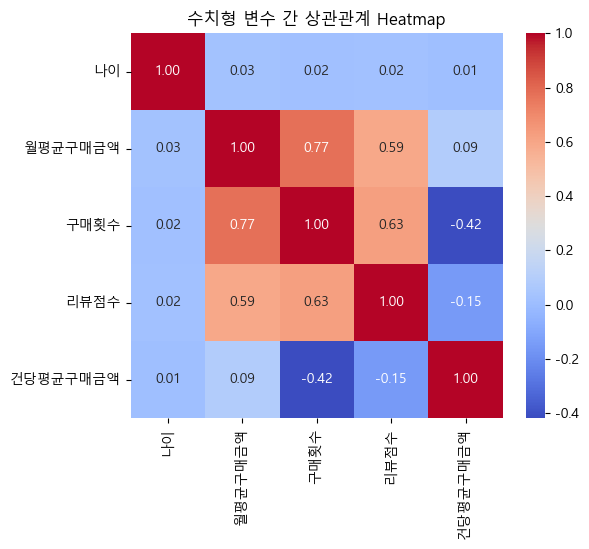

In [15]:
corr = df[num_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('수치형 변수 간 상관관계 Heatmap')
plt.show()

In [17]:
# abs() --> 절대값
# sort_values(ascending=False) --> 값을 내림차순 정렬
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_pair = corr_pairs.abs().sort_values(ascending=False).index[0]
print(f'최고 상관 변수 쌍 : {top_pair} r={corr.loc[top_pair]}')

최고 상관 변수 쌍 : ('월평균구매금액', '구매횟수') r=0.7733388270281819


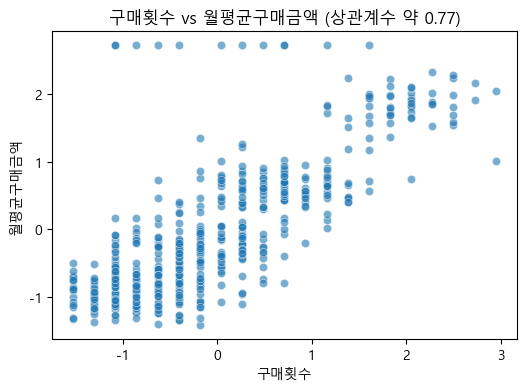

In [18]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='구매횟수', y='월평균구매금액', data=df, alpha=0.6)
plt.title('구매횟수 vs 월평균구매금액 (상관계수 약 0.77)')
plt.show()

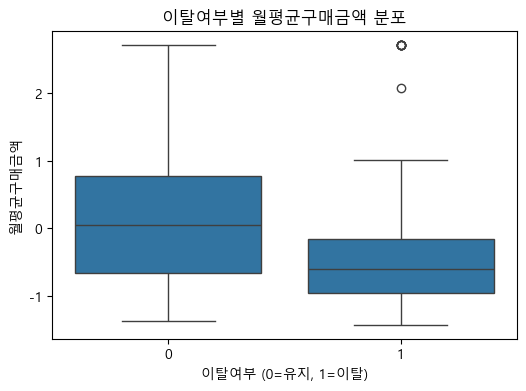

In [19]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='이탈여부', y='월평균구매금액', data=df)
plt.xlabel('이탈여부 (0=유지, 1=이탈)')
plt.title('이탈여부별 월평균구매금액 분포')
plt.show()

### 해석

- 구매횟수와 월평균구매금액은 상관계수 약 0.77로 강한 양의 상관관계를 보인다. 자주 구매하는 고객일수록 월평균 지출 금액도 큰 경향이 있다.
- 이탈한 고객(이탈여부=1)의 월평균구매금액 중앙값이 유지 고객(이탈여부=0)보다 낮게 나타나, 구매 금액이 적을수록 이탈 가능성이 높은 경향이 관찰된다.
- 다만 이는 상관관계이지 인과관계가 아니다. 예를 들어 구매금액이 적어서 이탈하는 것인지, 이탈을 앞둔 고객이 자연히 구매를 줄이는 것인지는 이 데이터만으로 구분할 수 없으며, 멤버십등급 등 제3의 변수가 두 변수 모두에 영향을 주는 가능성도 있다.

## 4. 그룹별 비교 분석 및 인사이트 도출

In [20]:
membership = {0: '브론즈', 1: '실버', 2: '골드', 3: 'VIP'}
df['멤버십등급_label'] = df['멤버십등급_encoded'].map(membership)

group_stats = df.groupby('멤버십등급_label')[['월평균구매금액', '이탈여부']].mean()
group_stats = group_stats.reindex(['브론즈', '실버', '골드', 'VIP'])
group_stats.columns = ['평균_월평균구매금액(표준화)', '이탈율']
group_stats

,평균_월평균구매금액(표준화),이탈율
멤버십등급_label,,
브론즈,-0.816720,0.557292
실버,-0.143816,0.422535
골드,0.684701,0.189189
VIP,1.840552,0.036364


In [21]:
pivot = pd.pivot_table(df, index='연령대', columns='멤버십등급_label',
                        values='이탈여부', aggfunc='mean')
pivot = pivot.reindex(index=['10대','20대','30대','40대','50대','60대이상'],
                       columns=['브론즈','실버','골드','VIP'])
pivot

멤버십등급_label,브론즈,실버,골드,VIP
연령대,,,,
10대,0.833333,0.333333,0.333333,0.000000
20대,0.545455,0.428571,0.333333,0.000000
30대,0.633333,0.407407,0.100000,0.000000
40대,0.547170,0.413793,0.133333,0.153846
50대,0.547619,0.500000,0.222222,0.000000
60대이상,0.464286,0.368421,0.125000,0.000000


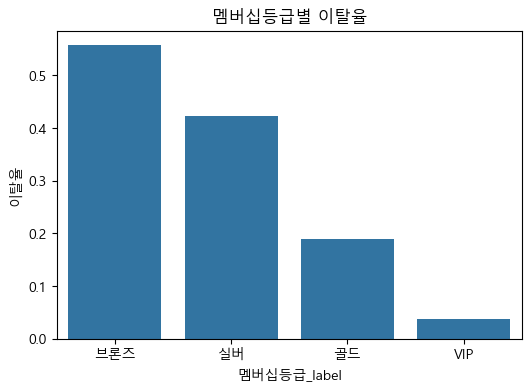

In [22]:
plt.figure(figsize=(6, 4))
sns.barplot(x=group_stats.index, y=group_stats['이탈율'], order=['브론즈','실버','골드','VIP'])
plt.title('멤버십등급별 이탈율')
plt.ylabel('이탈율')
plt.show()

### 비즈니스 인사이트

1. 멤버십등급이 낮을수록 이탈율이 급격히 높아진다 --> 브론즈 등급의 이탈율은 약 55.7%인 반면 VIP는 약 3.6%에 불과하다. 신규/저등급 고객을 실버 이상으로 승급시키는 프로모션이 이탈 방지에 효과적일 것으로 보인다.
2. 구매횟수와 구매금액이 강하게 연동된다(상관계수 0.77) --> 단순히 1회 구매 단가를 높이는 것보다 재구매 빈도를 유도하는 정기구독, 재구매 쿠폰 등 마케팅 활동이 매출 확대에 더 효과적일 수 있다.
3. 60대 이상 연령대의 이탈율(약 30.1%)이 전 연령대 중 가장 낮다. 반면 20대·50대는 41.7%로 상대적으로 높아, 젊은층과 중장년층을 대상으로 한 맞춤형 프로모션이 필요하다.